In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import re
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time

# Atur agar semua kolom terlihat
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_seq_items', None)
pd.options.display.max_rows = None
pd.options.display.max_columns = None 


In [3]:
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv', low_memory=False)

# review

In [33]:
df['Review Scores Rating'].unique()

array([  0. , 100. ,  95. ,  87. ,  96. ,  60. ,  85. ,  91. ,  99. ,
        94. ,  92. ,  98. ,  97. ,  90. ,  82. ,  80. ,  93. ,  77. ,
        83. ,  84. ,  70. ,  86. ,  89. ,  78. ,  88. ,  96.5,  81. ,
        79. ,  76. ,  73. ,  20. ,  74. ,  40. ,  72. ,  68. ,  99.5,
        67. ,  63. ,  55. ,  52. ,  53. ,  71. ,  97.5,  98.5,  69. ,
        75. ,  50. ,  65. ,  95.5,  89.5,  94.5,  30. ,  91.5,  66. ,
        64. ,  58. ,  35. ,  47. ,  27. ,  48. ,  92.5,  93.5,  43. ,
        62. ,  57. ,  56. ,  46. ,  49. ,  44. ,  87.5,  90.5,  54. ,
        33. ])

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Contoh fungsi untuk mengkategorikan rating
def categorize_rating(r):
    if r < 80:
        return "Low"
    elif 80 <= r < 95:
        return "Medium"
    else:
        return "High"

# Buat kolom kategori review rating di dataframe
df["Rating_Category"] = df["Review Scores Rating"].apply(categorize_rating)


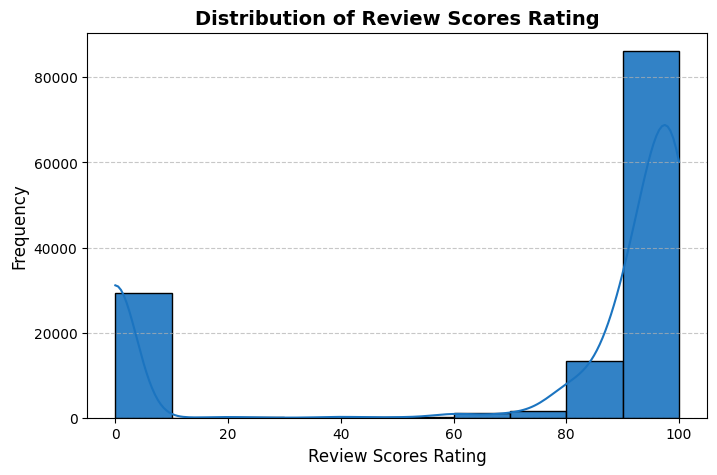

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5), facecolor='white')

# Plot histogram dengan bins = 10 agar lebih terbaca
sns.histplot(df["Review Scores Rating"], bins=10, kde=True, color="#1b74c0", edgecolor="black", alpha=0.9)

# Styling
plt.xlabel("Review Scores Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Review Scores Rating", fontsize=14, fontweight="bold")
plt.grid(axis='y', linestyle="--", alpha=0.7)

plt.show()


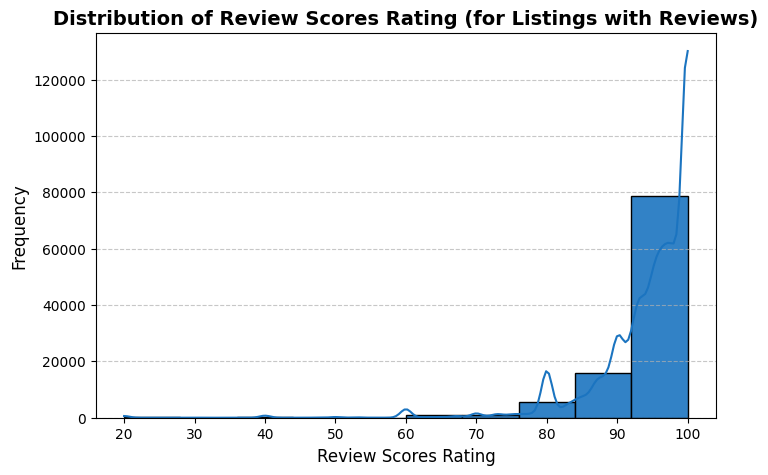

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter hanya properti yang memiliki review (> 0)
df_filtered = df[df["Number of Reviews"] > 0].copy()

plt.figure(figsize=(8,5), facecolor='white')

# Plot histogram dengan bins = 10 agar lebih terbaca
sns.histplot(df_filtered["Review Scores Rating"], bins=10, kde=True, color="#1b74c0", edgecolor="black", alpha=0.9)

# Styling
plt.xlabel("Review Scores Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Review Scores Rating (for Listings with Reviews)", fontsize=14, fontweight="bold")
plt.grid(axis='y', linestyle="--", alpha=0.7)

plt.show()


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\1655398274.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\1655398274.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\1655398274.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\1655398274.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

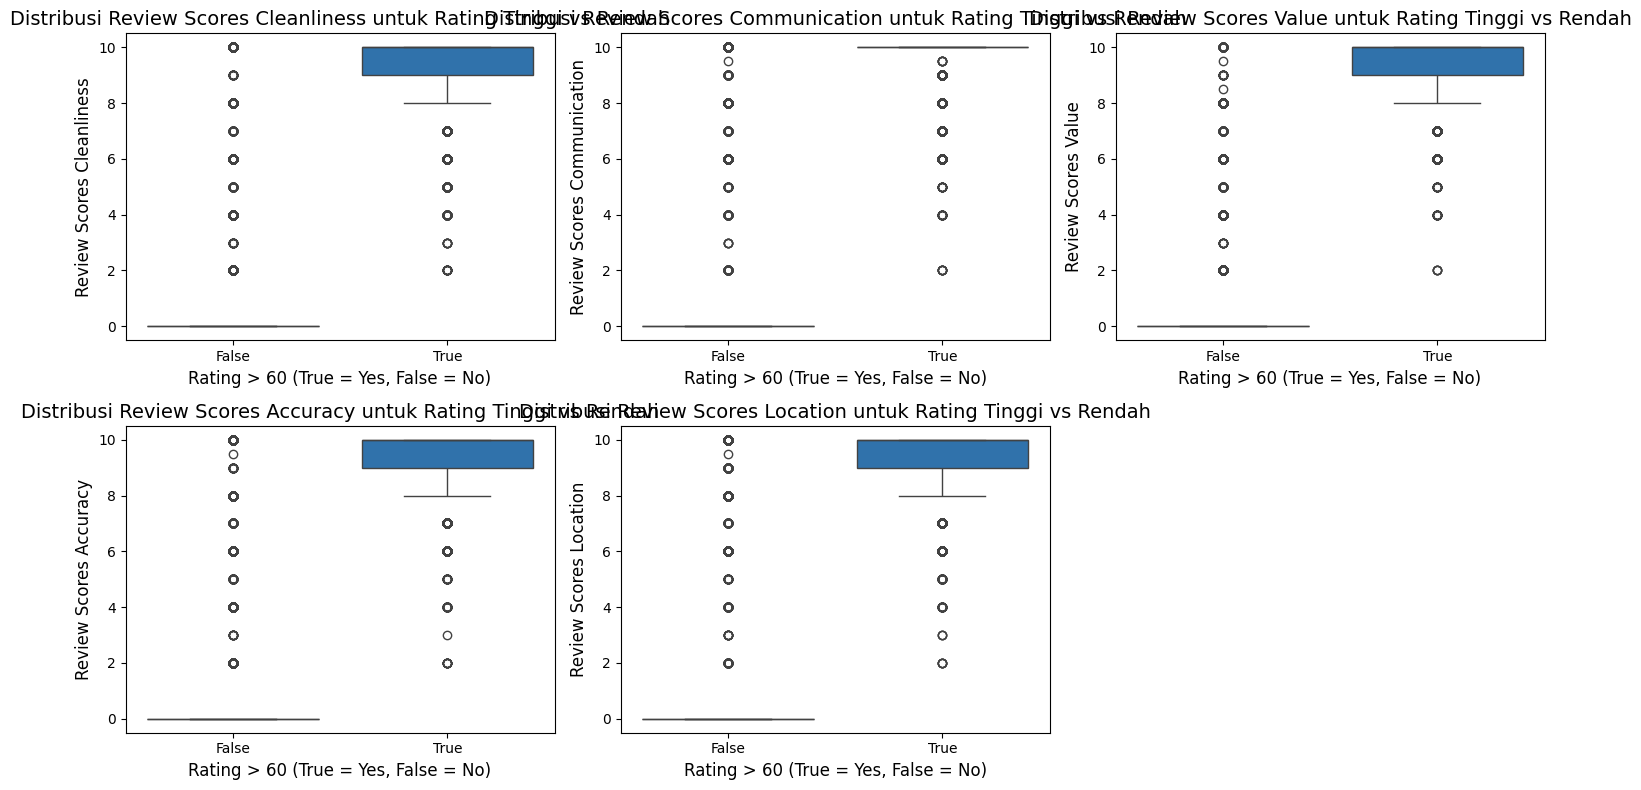

<Figure size 1000x600 with 0 Axes>

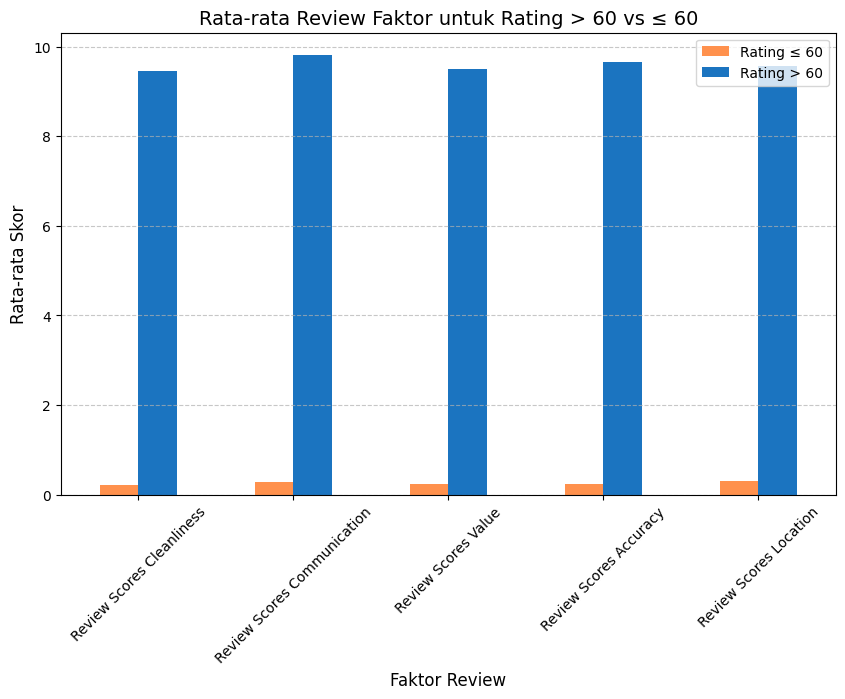

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Buat kategori berdasarkan rating
df["High Rating"] = df["Review Scores Rating"] > 60  # True untuk rating > 60

# Pilih faktor review yang akan dibandingkan
review_factors = [
    "Review Scores Cleanliness", 
    "Review Scores Communication", 
    "Review Scores Value", 
    "Review Scores Accuracy", 
    "Review Scores Location"
]

# **1️⃣ Boxplot: Distribusi faktor antara rating tinggi vs rendah**
plt.figure(figsize=(15, 8))
for i, factor in enumerate(review_factors, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df["High Rating"], y=df[factor], palette=["#FF914D", "#1b74c0"])
    plt.xlabel("Rating > 60 (True = Yes, False = No)", fontsize=12)
    plt.ylabel(factor, fontsize=12)
    plt.title(f"Distribusi {factor} untuk Rating Tinggi vs Rendah", fontsize=14)

plt.tight_layout()
plt.show()

# **2️⃣ Bar Chart: Rata-rata faktor review untuk Rating > 60 vs ≤ 60**
plt.figure(figsize=(10,6))
avg_factors = df.groupby("High Rating")[review_factors].mean()
avg_factors.T.plot(kind="bar", figsize=(10,6), color=["#FF914D", "#1b74c0"])

plt.xlabel("Faktor Review", fontsize=12)
plt.ylabel("Rata-rata Skor", fontsize=12)
plt.title("Rata-rata Review Faktor untuk Rating > 60 vs ≤ 60", fontsize=14)
plt.xticks(rotation=45)
plt.legend(["Rating ≤ 60", "Rating > 60"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\1676480664.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\1676480664.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\1676480664.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\1676480664.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

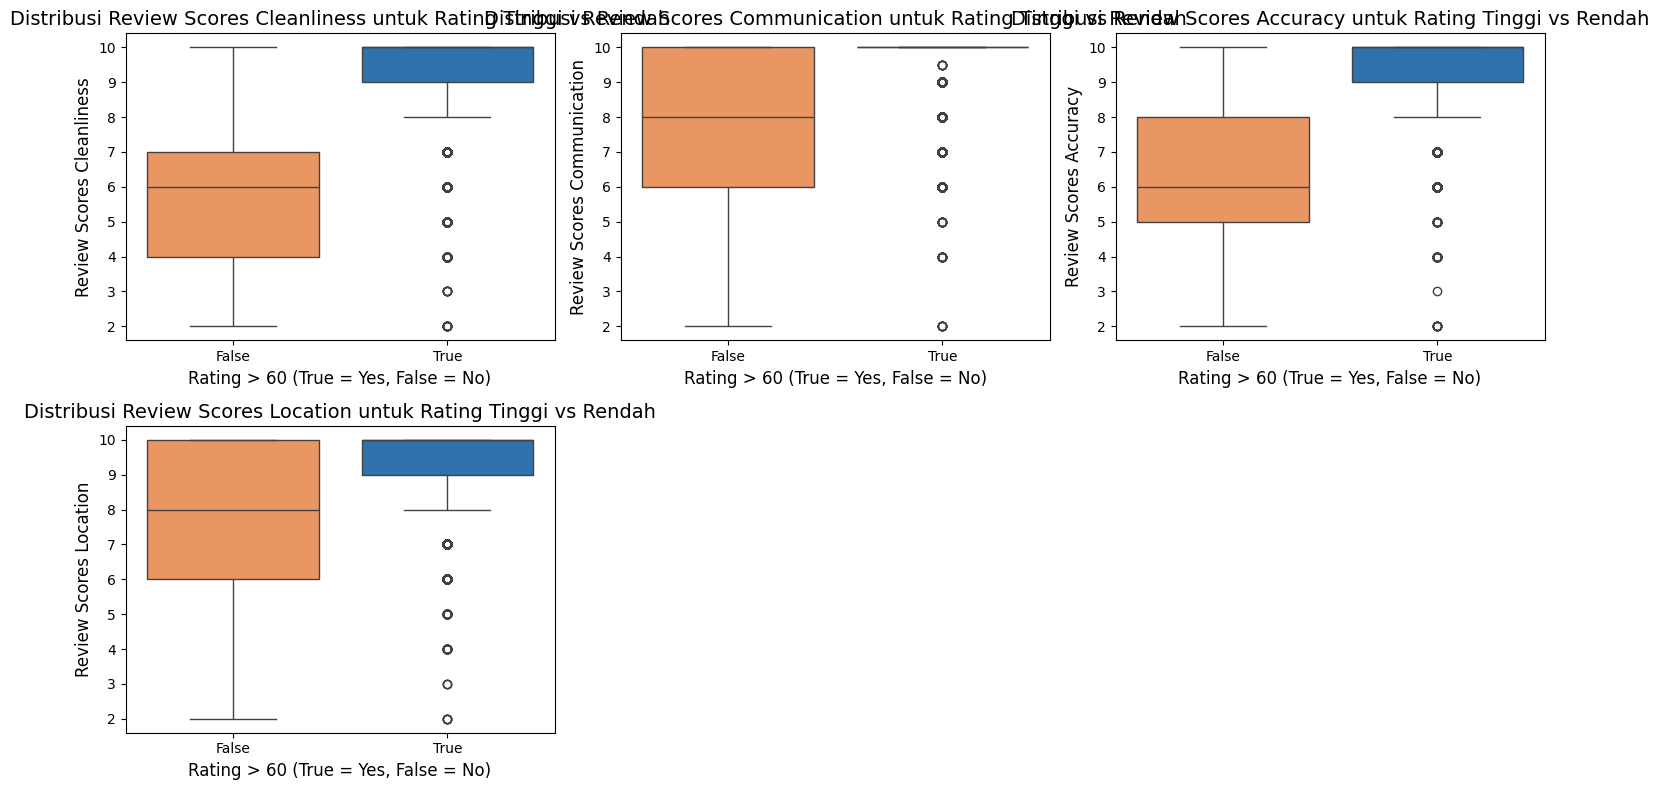

<Figure size 1000x600 with 0 Axes>

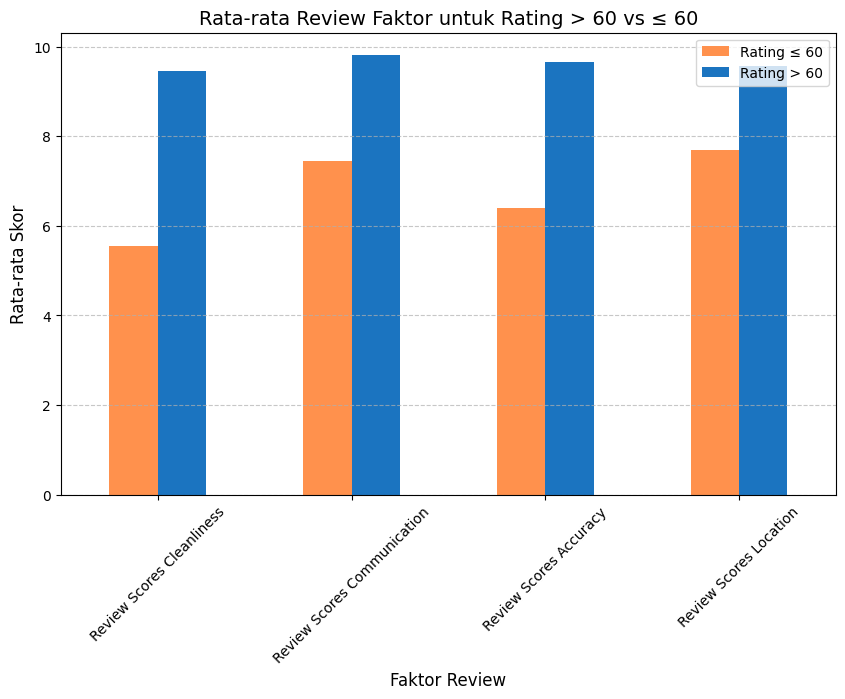

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter hanya properti yang memiliki review (> 0)
df_filtered = df[df["Number of Reviews"] > 0].copy()

# Buat kategori berdasarkan rating
df_filtered["High Rating"] = df_filtered["Review Scores Rating"] > 60  # True untuk rating > 60

# Pilih faktor review yang akan dibandingkan
review_factors = [
    "Review Scores Cleanliness", 
    "Review Scores Communication", 
    "Review Scores Accuracy", 
    "Review Scores Location"
]

# **1️⃣ Boxplot: Distribusi faktor antara rating tinggi vs rendah**
plt.figure(figsize=(15, 8))
for i, factor in enumerate(review_factors, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_filtered["High Rating"], y=df_filtered[factor], palette=["#FF914D", "#1b74c0"])
    plt.xlabel("Rating > 60 (True = Yes, False = No)", fontsize=12)
    plt.ylabel(factor, fontsize=12)
    plt.title(f"Distribusi {factor} untuk Rating Tinggi vs Rendah", fontsize=14)

plt.tight_layout()
plt.show()

# **2️⃣ Bar Chart: Rata-rata faktor review untuk Rating > 60 vs ≤ 60**
plt.figure(figsize=(10,6))
avg_factors = df_filtered.groupby("High Rating")[review_factors].mean()
avg_factors.T.plot(kind="bar", figsize=(10,6), color=["#FF914D", "#1b74c0"])

plt.xlabel("Faktor Review", fontsize=12)
plt.ylabel("Rata-rata Skor", fontsize=12)
plt.title("Rata-rata Review Faktor untuk Rating > 60 vs ≤ 60", fontsize=14)
plt.xticks(rotation=45)
plt.legend(["Rating ≤ 60", "Rating > 60"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


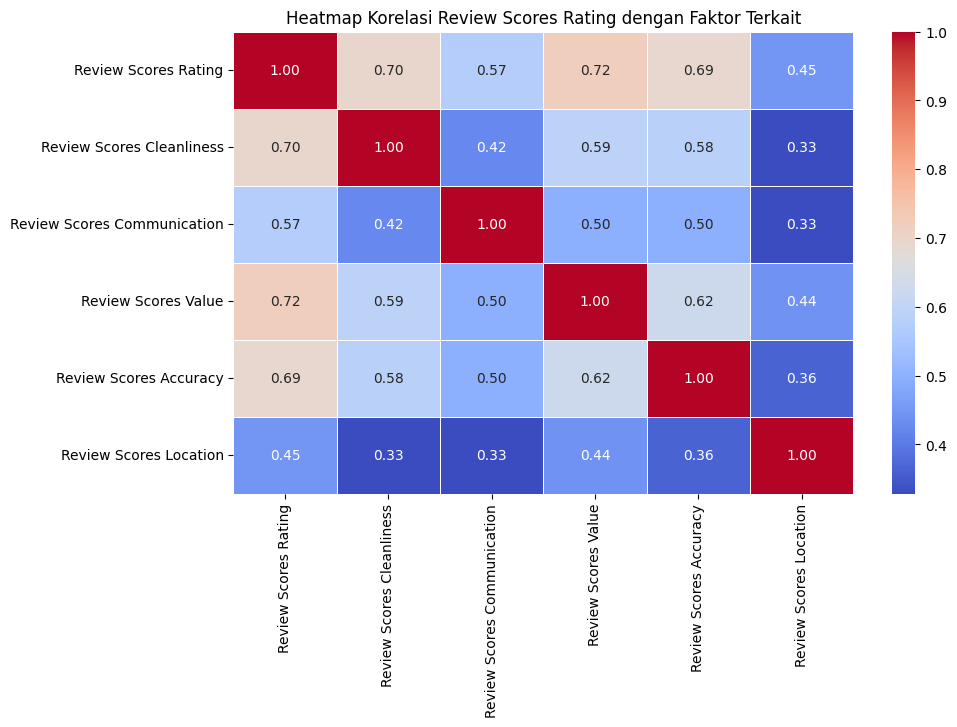

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pilih kolom yang berkaitan dengan Review Scores
cols = [
    "Review Scores Rating", 
    "Review Scores Cleanliness", 
    "Review Scores Communication", 
    "Review Scores Value", 
    "Review Scores Accuracy", 
    "Review Scores Location"
]

# Filter hanya rating > 20
df_filtered = df[df["Review Scores Rating"] > 20][cols]

# Hitung korelasi
corr_matrix = df_filtered.corr()

# Plot heatmap korelasi
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Review Scores Rating dengan Faktor Terkait")
plt.show()


In [36]:
grouped_data = df.groupby("Rating_Category")["Price"].mean().reset_index()
grouped_data.rename(columns={"Price": "Avg_Price"}, inplace=True)
print(grouped_data)


  Rating_Category   Avg_Price
0            High  153.230963
1             Low  182.674281
2          Medium  136.221830


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\2826292089.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




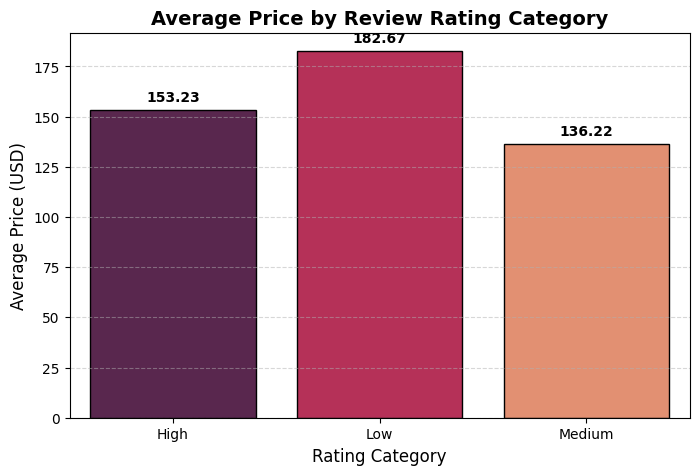

In [37]:
plt.figure(figsize=(8, 5), facecolor='white')

sns.barplot(data=grouped_data, x="Rating_Category", y="Avg_Price", 
            palette="rocket", edgecolor="black")

plt.title("Average Price by Review Rating Category", fontsize=14, fontweight="bold")
plt.xlabel("Rating Category", fontsize=12)
plt.ylabel("Average Price (USD)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Tambahkan label nilai di atas setiap bar
for index, row in grouped_data.iterrows():
    plt.text(index, row["Avg_Price"] + 3, f"{row['Avg_Price']:.2f}", 
             ha="center", va="bottom", color="black", fontweight="bold")

plt.show()


In [4]:
df.head()

,Last Scraped,Host Since,Host Response Time,Host Response Rate,Host Neighbourhood,Host Total Listings Count,Neighbourhood,City,State,Zipcode,Latitude,Longitude,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Bed Type,Amenities,Price,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Calendar Updated,Availability 30,Availability 60,Availability 90,Availability 365,Calendar last Scraped,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Cancellation Policy,Calculated host listings count,Reviews per Month,Wireless Internet,Heating,Kitchen,Essentials,TV,Smoke detector,Shampoo,Internet,Washer,Dryer
0,2017-05-02,2014-11-22 00:00:00,within an hour,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91364,34.147756,-118.591338,Apartment,Private room,2.0,1,1,1,Real Bed,"TV,Wireless Internet,Air conditioning,Free parking on premises,Hot tub,Heating,Smoke detector,Carbon monoxide detector,Essentials,Shampoo",150.0,25.0,1.0,0.0,1.0,1125.0,29 months ago,30.0,60.0,90.0,365.0,2017-05-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flexible,1.0,0.00,True,True,False,True,True,True,True,True,False,False
1,2017-05-03,2016-02-02 00:00:00,within a day,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91364,34.164597,-118.600512,House,Entire home/apt,8.0,3,4,4,Real Bed,"Wireless Internet,Air conditioning,Pool,Kitchen,Free parking on premises,Pets allowed,Indoor fireplace,Heating,Family/kid friendly,Washer,Dryer,Smoke detector,Carbon monoxide detector,First aid kit,Safety card,Essentials,Shampoo,Hangers,Hair dryer,Iron,Laptop friendly workspace,TV",175.0,150.0,8.0,25.0,2.0,1125.0,today,9.0,19.0,28.0,28.0,2017-05-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flexible,1.0,0.00,True,True,True,True,True,True,True,True,True,True
2,2017-05-03,2016-11-22 00:00:00,within a few hours,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91367,34.183150,-118.645064,Guesthouse,Entire home/apt,3.0,1,1,1,Real Bed,"TV,Wireless Internet,Air conditioning,Kitchen,Free parking on premises,Heating,Family/kid friendly,Washer,Dryer,Smoke detector,Carbon monoxide detector,Essentials,Hangers,Laptop friendly workspace",79.0,55.0,1.0,25.0,2.0,26.0,yesterday,30.0,60.0,90.0,90.0,2017-05-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flexible,1.0,0.00,True,True,True,True,True,True,False,True,True,True
3,2017-05-03,2011-04-13 00:00:00,within a few hours,100.0,Woodland Hills/Warner Center,2,Woodland Hills,Woodland Hills,CA,91364,34.148594,-118.596684,Other,Entire home/apt,2.0,1,1,1,Real Bed,"TV,Cable TV,Wireless Internet,Air conditioning,Kitchen,Free parking on premises,Heating,Washer,Dryer,Smoke detector,Carbon monoxide detector,First aid kit,Fire extinguisher,Essentials,Shampoo,Hangers,Hair dryer,Iron,translation missing: en.hosting_amenity_49,translation missing: en.hosting_amenity_50",175.0,100.0,1.0,0.0,2.0,5.0,2 weeks ago,12.0,42.0,72.0,72.0,2017-05-03,2.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,strict,2.0,0.16,True,True,True,True,True,True,True,True,True,True
4,2017-05-03,2015-01-03 00:00:00,within an hour,100.0,Studio City,36,Woodland Hills,Los Angeles,CA,91367,34.174245,-118.605876,Townhouse,Entire home/apt,6.0,2,3,4,Real Bed,"TV,Cable TV,Internet,Wireless Internet,Air conditioning,Pool,Kitchen,Free parking on premises,Pets allowed,Hot tub,Indoor fireplace,Heating,Family/kid friendly,Suitable for events,Washer,Dryer,Smoke detector,First aid kit,Safety card,Fire extinguisher,Essentials,Hangers,Hair dryer,Iron,Laptop friendly workspace",450.0,200.0,6.0,50.0,3.0,1125.0,today,26.0,56.0,86.0,361.0,2017-05-03,8.0,95.0,9.0,10.0,10.0,10.0,9.0,10.0,moderate,29.0,0.79,True,True,True,True,True,True,False,True,True,True


# price distribution

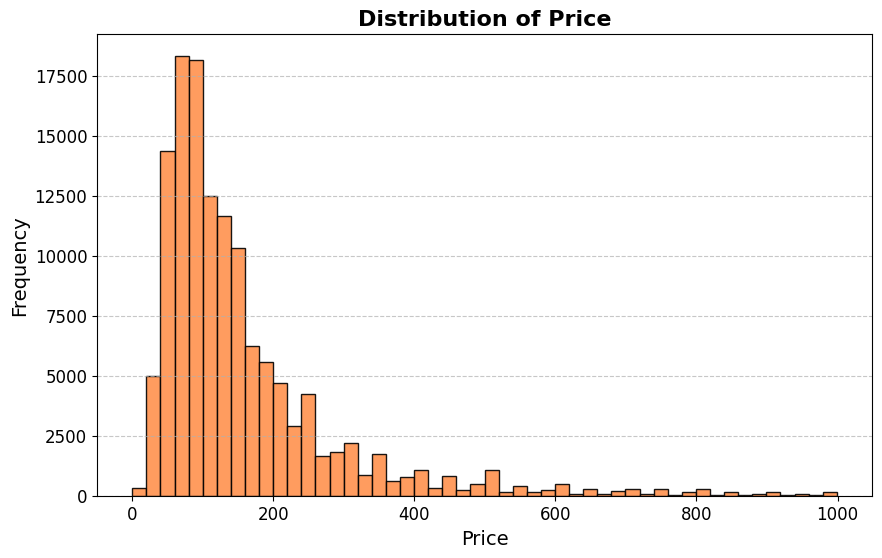

In [7]:
# Gantilah df dengan dataset aslimu jika tersedia
plt.figure(figsize=(10,6), facecolor='white')
plt.hist(df['Price'], bins=50, color='#FF914D', edgecolor='black', alpha=0.9)

# Styling
plt.xlabel("Price", fontsize=14, color='black')
plt.ylabel("Frequency", fontsize=14, color='black')
plt.title("Distribution of Price", fontsize=16, fontweight='bold', color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

# Show plot
plt.show()

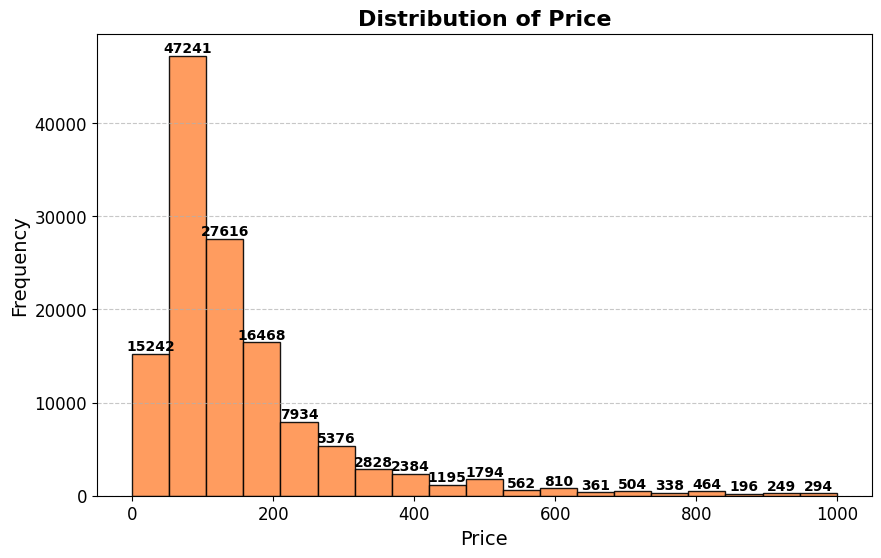

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Tentukan jumlah bin yang lebih optimal
bin_edges = np.histogram_bin_edges(df['Price'], bins='sturges')  # Gunakan aturan Sturges untuk binning optimal

# Buat histogram
plt.figure(figsize=(10, 6), facecolor='white')
counts, bins, patches = plt.hist(df['Price'], bins=bin_edges, color='#FF914D', edgecolor='black', alpha=0.9)

# Tambahkan label pada setiap bar histogram
for count, bin_edge in zip(counts, bins[:-1]):
    plt.text(bin_edge + (bins[1] - bins[0]) / 2, count + 5, str(int(count)), 
             ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

# Styling
plt.xlabel("Price", fontsize=14, color='black')
plt.ylabel("Frequency", fontsize=14, color='black')
plt.title("Distribution of Price", fontsize=16, fontweight='bold', color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

# Tampilkan plot
plt.show()


In [17]:
import pandas as pd

# 1. Baca data mentah (misal nama file 'data_price.csv' dengan kolom 'Price')
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2. Definisikan bin dan label bin sesuai kebutuhan
#    Contoh bin manual: 0, 50, 100, 150, 200, 300, 400, ...
bins = [0, 50, 100, 150, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
labels = [
    '0-50',
    '51-100',
    '101-150',
    '151-200',
    '201-300',
    '301-400',
    '401-500',
    '501-600',
    '601-700',
    '701-800',
    '801-900',
    '901-1000'
]

# 3. Membuat kolom kategori (Price Range) berdasarkan bin
df['Price Range'] = pd.cut(df['Price'], bins=bins, labels=labels, include_lowest=True)

# 4. Menghitung frekuensi per bin
freq_df = df.groupby('Price Range').size().reset_index(name='Frequency')

# 5. Simpan hasil ke CSV
freq_df.to_csv('data_for_canva.csv', index=False)


C:\Users\Aufii\AppData\Local\Temp\ipykernel_36060\4236037863.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_df = df.groupby('Price Range').size().reset_index(name='Frequency')


In [5]:
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import HeatMap
import branca.colormap as cm

# 1️⃣ Load dataset
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Pastikan dataset punya kolom: 'State', 'Latitude', 'Longitude', 'Price'
df_grouped = df.groupby('State').agg({'Price': 'mean', 'Latitude': 'mean', 'Longitude': 'mean'}).reset_index()

# 3️⃣ Load GeoJSON file (batas negara bagian AS)
geojson_path = 'us-states.json'  # Pastikan file ini ada di direktori yang sama
try:
    geo_data = gpd.read_file(geojson_path)
    print("✅ GeoJSON berhasil dimuat!")
except Exception as e:
    print(f"❌ Error saat memuat GeoJSON: {e}")
    exit()

# 4️⃣ Buat peta dengan Folium
m = folium.Map(location=[df_grouped['Latitude'].mean(), df_grouped['Longitude'].mean()], zoom_start=5)

# 5️⃣ Custom Colormap untuk legenda warna
custom_colormap = cm.LinearColormap(
    colors=["blue", "#ffde59", "#ffbd59", "#ff914d", "#e86b47"],
    vmin=df_grouped["Price"].min(),
    vmax=df_grouped["Price"].max(),
    caption="Average Airbnb Price"
)

# 6️⃣ Buat Choropleth Map (gunakan skema warna bawaan Folium)
choropleth = folium.Choropleth(
    geo_data=geojson_path,
    name="Airbnb Price Heatmap",
    data=df_grouped,
    columns=["State", "Price"],
    key_on="feature.properties.name",  # Pastikan ini sesuai dengan GeoJSON
    fill_color="YlOrRd",  # Warna yang kompatibel dengan Folium
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Average Airbnb Price per Region"
).add_to(m)

# 7️⃣ Tambahkan marker untuk harga rata-rata per wilayah
for _, row in df_grouped.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=6,
        color="black",
        fill=True,
        fill_color=custom_colormap(row["Price"]),  # Gunakan colormap hanya untuk marker
        fill_opacity=0.8,
        popup=f"{row['State']}: ${row['Price']:.2f}"
    ).add_to(m)

# 8️⃣ Tambahkan legenda warna kustom
m.add_child(custom_colormap)

# 9️⃣ Simpan peta sebagai HTML
m.save("airbnb_price_map.html")
print("\n🚀 Map has been saved as 'airbnb_price_map.html'. Open it in your browser!")


✅ GeoJSON berhasil dimuat!

🚀 Map has been saved as 'airbnb_price_map.html'. Open it in your browser!


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131856 entries, 0 to 131855
Data columns (total 53 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Last Scraped                    131856 non-null  object 
 1   Host Since                      131856 non-null  object 
 2   Host Response Time              131856 non-null  object 
 3   Host Response Rate              131856 non-null  float64
 4   Host Neighbourhood              131856 non-null  object 
 5   Host Total Listings Count       131856 non-null  int64  
 6   Neighbourhood                   131856 non-null  object 
 7   City                            131856 non-null  object 
 8   State                           131856 non-null  object 
 9   Zipcode                         131856 non-null  int64  
 10  Latitude                        131856 non-null  float64
 11  Longitude                       131856 non-null  float64
 12  Property Type   

In [12]:
import pandas as pd
import folium
from folium.plugins import HeatMap
from sklearn.preprocessing import MinMaxScaler

# 1️⃣ Load dataset
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per City
df_grouped = df.groupby('City').agg({'Price': 'mean', 'Latitude': 'mean', 'Longitude': 'mean'}).reset_index()

# 3️⃣ Normalisasi Harga (Agar heatmap lebih jelas)
scaler = MinMaxScaler(feature_range=(0, 1))
df_grouped['Price_Norm'] = scaler.fit_transform(df_grouped[['Price']])  # Skala 0-1

# 4️⃣ Buat peta dasar
m = folium.Map(location=[df_grouped['Latitude'].mean(), df_grouped['Longitude'].mean()], zoom_start=5)

# 5️⃣ Buat data untuk HeatMap (format: [lat, lon, value])
heat_data = [[row["Latitude"], row["Longitude"], row["Price_Norm"]] for _, row in df_grouped.iterrows()]

# 6️⃣ Tambahkan HeatMap ke peta
HeatMap(
    heat_data,
    min_opacity=0.3,  
    max_opacity=0.8,  
    radius=25,  
    blur=15,  
    gradient={
    "0.2": "blue", 
    "0.4": "#ffde59", 
    "0.6": "#ffbd59", 
    "0.8": "#ff914d", 
    "1.0": "#e86b47"
    }
).add_to(m)

# 7️⃣ Simpan peta sebagai HTML
m.save("airbnb_price_heatmap2.html")
print("\n🚀 Heatmap telah disimpan sebagai 'airbnb_price_heatmap.html'. Buka di browser untuk melihat hasilnya!")



🚀 Heatmap telah disimpan sebagai 'airbnb_price_heatmap.html'. Buka di browser untuk melihat hasilnya!


In [13]:
import pandas as pd
import folium
import json

# 1️⃣ Load dataset
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean', 'Latitude': 'mean', 'Longitude': 'mean'}).reset_index()

# 3️⃣ Load GeoJSON batas negara bagian AS
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"

# 4️⃣ Buat peta dasar
m = folium.Map(location=[df_grouped['Latitude'].mean(), df_grouped['Longitude'].mean()], zoom_start=5)

# 5️⃣ Tambahkan Choropleth Map dengan warna sesuai harga rata-rata
choropleth = folium.Choropleth(
    geo_data=geojson_url,
    name="Airbnb Price Heatmap",
    data=df_grouped,
    columns=["State", "Price"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",  # Skema warna dari kuning ke merah
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Average Airbnb Price per State",
    highlight=True
).add_to(m)

# 6️⃣ Tambahkan label harga di setiap State
for _, row in df_grouped.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        icon=folium.DivIcon(html=f"""
            <div style="font-size: 10pt; font-weight: bold; text-align: center; 
                        background-color: rgba(255,255,255,0.7); padding: 3px; border-radius: 5px;">
                {row["State"]}: ${row["Price"]:.2f}
            </div>
        """)
    ).add_to(m)

# 7️⃣ Simpan peta sebagai HTML
m.save("airbnb_price_per_state.html")
print("\n🚀 Peta telah disimpan sebagai 'airbnb_price_per_state.html'. Buka di browser untuk melihat hasilnya!")



🚀 Peta telah disimpan sebagai 'airbnb_price_per_state.html'. Buka di browser untuk melihat hasilnya!



🚀 Peta telah disimpan sebagai 'airbnb_price_per_state.png'. Gunakan gambar ini untuk presentasi!


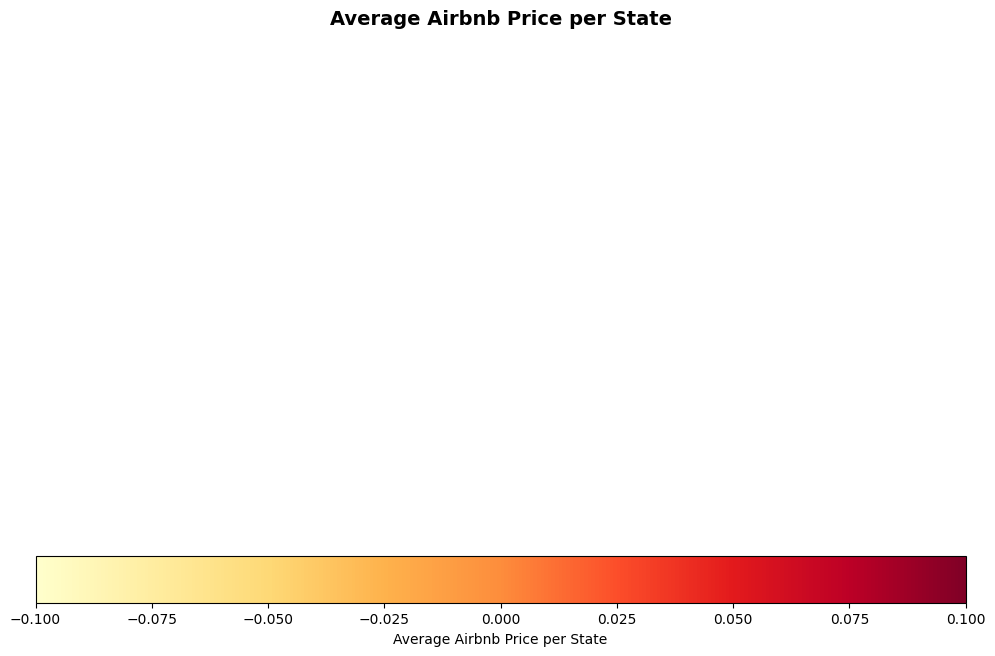

In [14]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Load GeoJSON batas negara bagian AS (GeoPandas)
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
gdf = gpd.read_file(geojson_url)

# 4️⃣ Gabungkan data harga Airbnb dengan GeoDataFrame
gdf = gdf.merge(df_grouped, how="left", left_on="name", right_on="State")

# 5️⃣ Plot Peta
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf.plot(column="Price", cmap="YlOrRd", linewidth=0.8, edgecolor="black",
         legend=True, legend_kwds={'label': "Average Airbnb Price per State", 'orientation': "horizontal"}, ax=ax)

# 6️⃣ Tambahkan Label Harga di Setiap State
for _, row in gdf.iterrows():
    if not pd.isna(row["Price"]):  # Pastikan ada data harga
        plt.text(row["geometry"].centroid.x, row["geometry"].centroid.y, 
                 f"${row['Price']:.0f}", fontsize=8, ha="center", color="black", weight="bold")

# 7️⃣ Hapus axis untuk tampilan lebih bersih
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
ax.set_title("Average Airbnb Price per State", fontsize=14, fontweight="bold")

# 8️⃣ Simpan gambar
# plt.savefig("airbnb_price_per_state.png", dpi=300, bbox_inches="tight")
print("\n🚀 Peta telah disimpan sebagai 'airbnb_price_per_state.png'. Gunakan gambar ini untuk presentasi!")

# 9️⃣ Tampilkan Peta
plt.show()



🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_latlon_fixed.png'. Gunakan gambar ini untuk presentasi!


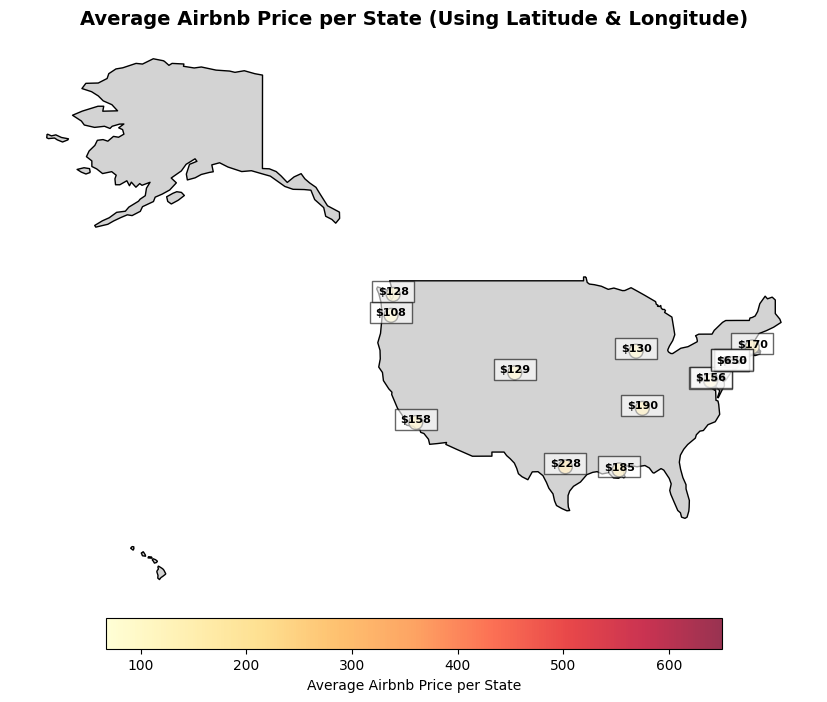

In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State, termasuk Latitude & Longitude
df_grouped = df.groupby('State').agg({'Price': 'mean', 'Latitude': 'mean', 'Longitude': 'mean'}).reset_index()

# 3️⃣ Load peta Amerika Serikat dari GeoJSON (gunakan dataset dari Natural Earth)
geojson_url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/USA.geo.json"
usa = gpd.read_file(geojson_url)

# 4️⃣ Buat plot peta
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
usa.plot(ax=ax, color="lightgrey", edgecolor="black")  # Plot peta AS

# 5️⃣ Scatter plot lokasi setiap state berdasarkan Latitude & Longitude
scatter = ax.scatter(df_grouped["Longitude"], df_grouped["Latitude"], 
                     c=df_grouped["Price"], cmap="YlOrRd", s=100, edgecolors="black", alpha=0.8)

# 6️⃣ Tambahkan Label Harga di Setiap Titik
for _, row in df_grouped.iterrows():
    plt.text(row["Longitude"], row["Latitude"], f"${row['Price']:.0f}", 
             fontsize=8, ha="center", color="black", weight="bold", 
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='black'))

# 7️⃣ Tambahkan colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", fraction=0.05, pad=0.02)
cbar.set_label("Average Airbnb Price per State")

# 8️⃣ Bersihkan tampilan peta
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
ax.set_title("Average Airbnb Price per State (Using Latitude & Longitude)", fontsize=14, fontweight="bold")

# 9️⃣ Simpan gambar
# plt.savefig("airbnb_price_per_state_latlon_fixed.png", dpi=300, bbox_inches="tight")
print("\n🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_latlon_fixed.png'. Gunakan gambar ini untuk presentasi!")

# 🔟 Tampilkan peta
plt.show()


In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Load peta negara bagian AS dari GeoJSON
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
gdf = gpd.read_file(geojson_url)

# 4️⃣ Gabungkan Data Airbnb dengan GeoDataFrame berdasarkan nama state
gdf = gdf.merge(df_grouped, how="left", left_on="name", right_on="State")

# 5️⃣ Buat kategori warna harga berdasarkan kuantil (mirip dengan contoh)
gdf["Price_Category"] = pd.qcut(gdf["Price"], q=5, labels=["0 - 9%", "10 - 19%", "20 - 29%", "30 - 39%", "40 - 50%"])

# 6️⃣ Mapping warna sesuai kategori harga
color_dict = {
    "0 - 9%": "#FFF5D9",   # Kuning muda
    "10 - 19%": "#FED976",  # Kuning
    "20 - 29%": "#FEB24C",  # Oranye muda
    "30 - 39%": "#FD8D3C",  # Oranye tua
    "40 - 50%": "#E31A1C",  # Merah tua
}

# 7️⃣ Plot Peta
fig, ax = plt.subplots(1, 1, figsize=(14, 9))

# Plot negara bagian dengan warna kategori harga
gdf.plot(column="Price_Category", cmap="YlOrRd", linewidth=0.8, edgecolor="white", legend=True, ax=ax)

# 8️⃣ Tambahkan Label Kode State di Tengah Wilayah
for _, row in gdf.iterrows():
    if not pd.isna(row["Price"]):  # Pastikan ada harga
        plt.text(row["geometry"].centroid.x, row["geometry"].centroid.y, 
                 row["State"], fontsize=10, ha="center", fontweight="bold", 
                 color="black", bbox=dict(facecolor="white", alpha=0.6, edgecolor="black"))

# 9️⃣ Bersihkan tampilan peta
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
ax.set_title("Average Airbnb Price per State", fontsize=16, fontweight="bold")

# 🔟 Simpan gambar
plt.savefig("airbnb_price_per_state_final.png", dpi=300, bbox_inches="tight")
print("\n🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_final.png'. Gunakan gambar ini untuk presentasi!")

# 🔟 Tampilkan Peta
plt.show()


ValueError: Bin edges must be unique: Index([nan, nan, nan, nan, nan, nan], dtype='float64', name='Price').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [21]:
import pandas as pd
import plotly.express as px
import json
import requests

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Mapping kode state ke nama lengkap
state_mapping = {
    "CA": "California", "TN": "Tennessee", "LA": "Louisiana", "TX": "Texas", "MA": "Massachusetts",
    "IL": "Illinois", "CO": "Colorado", "NY": "New York", "OR": "Oregon", "DC": "District of Columbia",
    "WA": "Washington", "MD": "Maryland", "VT": "Vermont", "NJ": "New Jersey", "MP": "Northern Mariana Islands"
}

df_grouped["State"] = df_grouped["State"].map(state_mapping).fillna(df_grouped["State"])

# 4️⃣ Load GeoJSON batas negara bagian AS
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
response = requests.get(geojson_url)
geojson_data = json.loads(response.text)

# 5️⃣ Buat peta interaktif dengan Plotly
fig = px.choropleth(
    df_grouped, 
    geojson=geojson_data, 
    locations="State", 
    featureidkey="properties.name", 
    color="Price",
    color_continuous_scale="YlOrRd",  # Warna dari kuning ke merah
    hover_name="State",  
    hover_data={"State": True, "Price": ":.2f"},  # Tooltip menampilkan state & price
    title="Average Airbnb Price per State",
    projection="albers usa"  # Proyeksi peta AS
)

# 6️⃣ Tampilkan peta
fig.update_geos(fitbounds="locations", visible=False)
fig.show()


In [20]:
df['State'].unique()

array(['CA', 'TN', 'LA', 'TX', 'MA', 'IL', 'CO', 'NY', 'OR', 'DC', 'WA',
       'MD', 'VT', 'NJ', 'MP'], dtype=object)

In [22]:
import pandas as pd
import plotly.express as px
import json
import requests

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Mapping kode state ke nama lengkap
state_mapping = {
    "CA": "California", "TN": "Tennessee", "LA": "Louisiana", "TX": "Texas", "MA": "Massachusetts",
    "IL": "Illinois", "CO": "Colorado", "NY": "New York", "OR": "Oregon", "DC": "District of Columbia",
    "WA": "Washington", "MD": "Maryland", "VT": "Vermont", "NJ": "New Jersey", "MP": "Northern Mariana Islands"
}

df_grouped["State"] = df_grouped["State"].map(state_mapping).fillna(df_grouped["State"])

# 4️⃣ Load GeoJSON batas negara bagian AS
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
response = requests.get(geojson_url)
geojson_data = json.loads(response.text)

# 5️⃣ Buat peta interaktif dengan batas putih antar state
fig = px.choropleth(
    df_grouped, 
    geojson=geojson_data, 
    locations="State", 
    featureidkey="properties.name", 
    color="Price",
    color_continuous_scale="YlOrRd",  # Skema warna kuning → merah
    hover_name="State",  
    hover_data={"State": True, "Price": ":.2f"},  # Tooltip menampilkan state & price
    title="Average Airbnb Price per State",
    projection="albers usa"  # Proyeksi peta AS
)

# 6️⃣ Tambahkan batas putih antar state
fig.update_geos(
    fitbounds="locations",
    visible=False,
    showcountries=True, 
    countrycolor="white",
    showsubunits=True, 
    subunitcolor="white"  # Menampilkan batas negara bagian dengan warna putih
)

# 7️⃣ Tambahkan teks nama state di tengah negara bagian
for feature in geojson_data["features"]:
    state_name = feature["properties"]["name"]
    centroid = feature["geometry"]["coordinates"][0][0]  # Ambil titik tengah state
    fig.add_annotation(
        x=centroid[0], 
        y=centroid[1], 
        text=state_name, 
        showarrow=False, 
        font=dict(size=10, color="black"), 
        align="center"
    )

# 8️⃣ Tampilkan peta
fig.show()


In [25]:
import pandas as pd
import plotly.express as px
import json
import requests
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Mapping kode state ke nama lengkap
state_mapping = {
    "CA": "California", "TN": "Tennessee", "LA": "Louisiana", "TX": "Texas", "MA": "Massachusetts",
    "IL": "Illinois", "CO": "Colorado", "NY": "New York", "OR": "Oregon", "DC": "District of Columbia",
    "WA": "Washington", "MD": "Maryland", "VT": "Vermont", "NJ": "New Jersey", "MP": "Northern Mariana Islands"
}

df_grouped["State"] = df_grouped["State"].map(state_mapping).fillna(df_grouped["State"])

# 4️⃣ Load GeoJSON batas negara bagian AS
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
response = requests.get(geojson_url)
geojson_data = json.loads(response.text)

# 5️⃣ Pastikan semua state tetap muncul (isi NaN dengan 0)
all_states = [feature["properties"]["name"] for feature in geojson_data["features"]]
df_all_states = pd.DataFrame({"State": all_states})
df_grouped = df_all_states.merge(df_grouped, on="State", how="left").fillna(0)

# 6️⃣ Buat peta interaktif dengan batas putih antar state
fig = px.choropleth(
    df_grouped, 
    geojson=geojson_data, 
    locations="State", 
    featureidkey="properties.name", 
    color="Price",
    color_continuous_scale="YlOrRd",  # Skema warna kuning → merah
    hover_name="State",  
    hover_data={"State": True, "Price": ":.2f"},  # Tooltip menampilkan state & price
    title="Average Airbnb Price per State",
    projection="albers usa"  # Proyeksi peta AS
)

# 7️⃣ Tambahkan batas putih antar state agar jelas
fig.update_geos(
    fitbounds="locations",
    visible=False,
    showcountries=True, 
    countrycolor="white",
    showsubunits=True, 
    subunitcolor="white"  # Menampilkan batas negara bagian dengan warna putih
)

# 8️⃣ Tambahkan label nama state di tengah tiap negara bagian
for feature in geojson_data["features"]:
    state_name = feature["properties"]["name"]
    coordinates = feature["geometry"]["coordinates"]

    # Cari centroid dengan menggunakan shapely
    if feature["geometry"]["type"] == "Polygon":
        polygon = Polygon(coordinates[0])
        centroid = polygon.centroid
    elif feature["geometry"]["type"] == "MultiPolygon":
        multipolygon = MultiPolygon([Polygon(p[0]) for p in coordinates])
        centroid = multipolygon.centroid
    else:
        continue  # Jika tidak berupa polygon, skip

    # Tambahkan label nama state di tengah setiap wilayah
    fig.add_annotation(
        x=centroid.x, 
        y=centroid.y, 
        text=state_name, 
        showarrow=False, 
        font=dict(size=10, color="black"), 
        align="center",
        bgcolor="white"
    )

# 9️⃣ Tampilkan peta
fig.show()


In [26]:
import pandas as pd
import plotly.express as px
import json
import requests
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Mapping kode state ke nama lengkap
state_mapping = {
    "CA": "California", "TN": "Tennessee", "LA": "Louisiana", "TX": "Texas", "MA": "Massachusetts",
    "IL": "Illinois", "CO": "Colorado", "NY": "New York", "OR": "Oregon", "DC": "District of Columbia",
    "WA": "Washington", "MD": "Maryland", "VT": "Vermont", "NJ": "New Jersey", "MP": "Northern Mariana Islands"
}

df_grouped["State"] = df_grouped["State"].map(state_mapping).fillna(df_grouped["State"])

# 4️⃣ Load GeoJSON batas negara bagian AS
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
response = requests.get(geojson_url)
geojson_data = json.loads(response.text)

# 5️⃣ Pastikan semua state tetap muncul (isi NaN dengan 0)
all_states = [feature["properties"]["name"] for feature in geojson_data["features"]]
df_all_states = pd.DataFrame({"State": all_states})
df_grouped = df_all_states.merge(df_grouped, on="State", how="left").fillna(0)

# 6️⃣ Buat peta interaktif dengan batas putih antar state
fig = px.choropleth(
    df_grouped, 
    geojson=geojson_data, 
    locations="State", 
    featureidkey="properties.name", 
    color="Price",
    color_continuous_scale="YlOrRd",  # Skema warna kuning → merah
    hover_name="State",  
    hover_data={"State": True, "Price": ":.2f"},  # Tooltip menampilkan state & price
    title="Average Airbnb Price per State",
    projection="albers usa"  # Proyeksi peta AS
)

# 7️⃣ Tambahkan batas putih antar state agar jelas
fig.update_geos(
    fitbounds="locations",
    visible=False,
    showcountries=True, 
    countrycolor="white",
    showsubunits=True, 
    subunitcolor="white"  # Menampilkan batas negara bagian dengan warna putih
)

# 8️⃣ Tambahkan label nama state di tengah tiap negara bagian
for feature in geojson_data["features"]:
    state_name = feature["properties"]["name"]
    coordinates = feature["geometry"]["coordinates"]

    # Cari centroid dengan menggunakan shapely
    if feature["geometry"]["type"] == "Polygon":
        polygon = Polygon(coordinates[0])
        centroid = polygon.centroid
    elif feature["geometry"]["type"] == "MultiPolygon":
        multipolygon = MultiPolygon([Polygon(p[0]) for p in coordinates])
        centroid = multipolygon.centroid
    else:
        continue  # Jika tidak berupa polygon, skip

    # Tambahkan label nama state di tengah setiap wilayah
    fig.add_annotation(
        x=centroid.x, 
        y=centroid.y, 
        text=state_name, 
        showarrow=False, 
        font=dict(size=9, color="black", family="Arial"), 
        align="center",
        bgcolor="white"  # Supaya tulisan terlihat jelas
    )

# 9️⃣ Tampilkan peta
fig.show()



🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_static.png'. Gunakan gambar ini untuk presentasi!


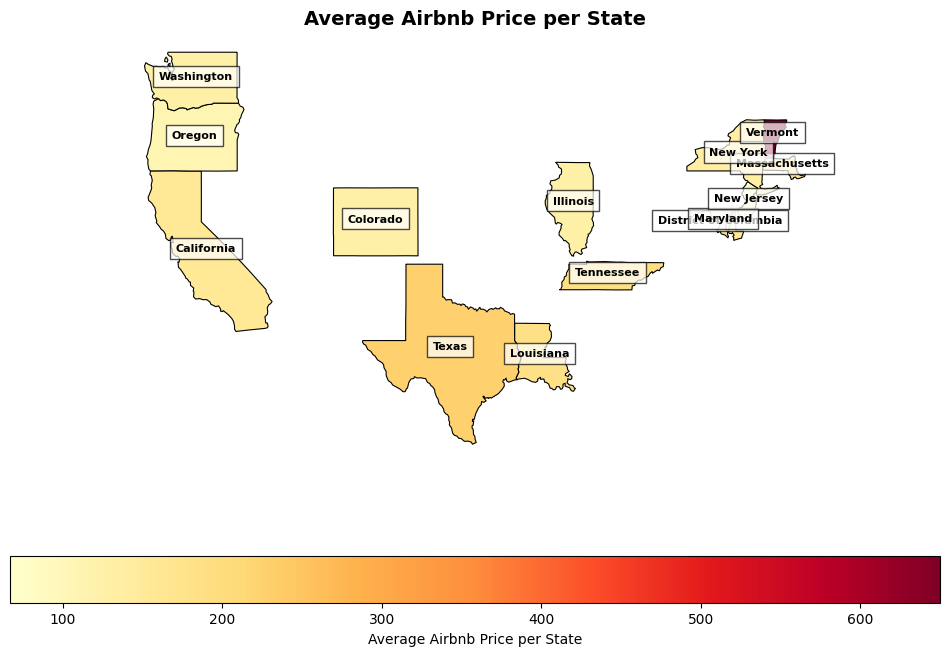

In [27]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Load shapefile USA dengan Geopandas
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
gdf = gpd.read_file(geojson_url)

# 4️⃣ Pastikan nama state cocok
state_mapping = {
    "CA": "California", "TN": "Tennessee", "LA": "Louisiana", "TX": "Texas", "MA": "Massachusetts",
    "IL": "Illinois", "CO": "Colorado", "NY": "New York", "OR": "Oregon", "DC": "District of Columbia",
    "WA": "Washington", "MD": "Maryland", "VT": "Vermont", "NJ": "New Jersey", "MP": "Northern Mariana Islands"
}
df_grouped["State"] = df_grouped["State"].map(state_mapping).fillna(df_grouped["State"])

# 5️⃣ Merge data harga dengan peta
gdf = gdf.merge(df_grouped, how="left", left_on="name", right_on="State")

# 6️⃣ Plot peta dengan warna harga
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf.plot(column="Price", cmap="YlOrRd", linewidth=0.8, edgecolor="black",
         legend=True, legend_kwds={'label': "Average Airbnb Price per State", 'orientation': "horizontal"}, ax=ax)

# 7️⃣ Tambahkan label nama state di tengah negara bagian
for _, row in gdf.iterrows():
    if not pd.isna(row["Price"]):  # Pastikan ada data harga
        centroid = row["geometry"].centroid
        plt.text(centroid.x, centroid.y, row["State"], fontsize=8, ha="center", weight="bold", color="black",
                 bbox=dict(facecolor="white", alpha=0.7, edgecolor="black"))

# 8️⃣ Bersihkan tampilan peta
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
ax.set_title("Average Airbnb Price per State", fontsize=14, fontweight="bold")

# 9️⃣ Simpan gambar
# plt.savefig("airbnb_price_per_state_static.png", dpi=300, bbox_inches="tight")
print("\n🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_static.png'. Gunakan gambar ini untuk presentasi!")

# 🔟 Tampilkan Peta
plt.show()



🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_final.png'. Gunakan gambar ini untuk presentasi!


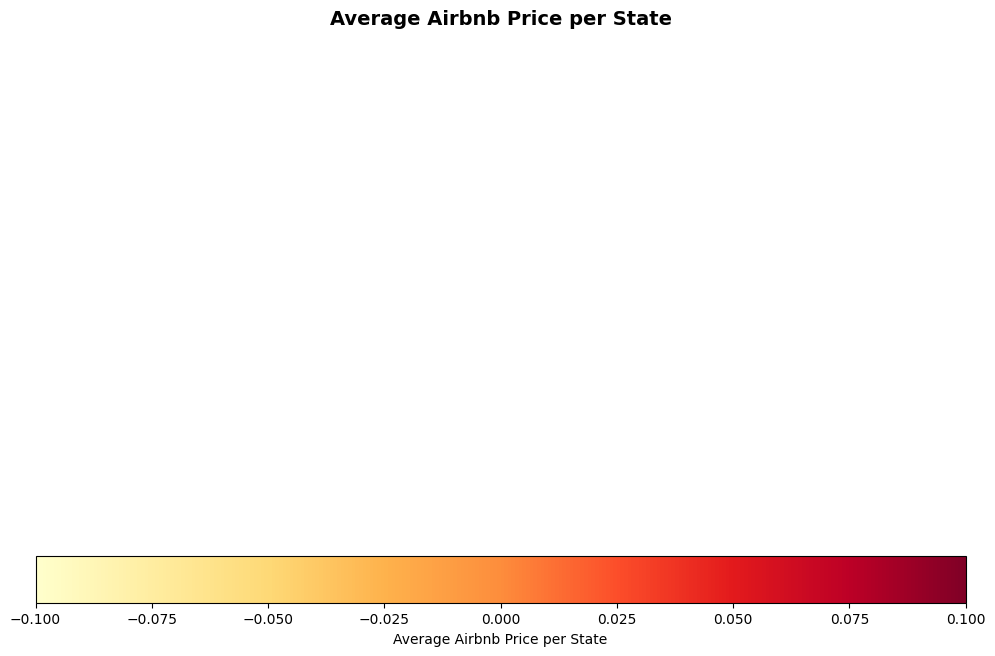

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Load GeoJSON batas negara bagian AS
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
gdf = gpd.read_file(geojson_url)

# 4️⃣ Pastikan format State menggunakan singkatan (misal CA, TX, NY)
state_abbreviations = {
    "California": "CA", "Tennessee": "TN", "Louisiana": "LA", "Texas": "TX", "Massachusetts": "MA",
    "Illinois": "IL", "Colorado": "CO", "New York": "NY", "Oregon": "OR", "District of Columbia": "DC",
    "Washington": "WA", "Maryland": "MD", "Vermont": "VT", "New Jersey": "NJ"
}

gdf["abbr"] = gdf["name"].map(state_abbreviations)

# 5️⃣ Merge data harga dengan peta
gdf = gdf.merge(df_grouped, how="left", left_on="name", right_on="State")

# 6️⃣ Plot peta dengan warna harga
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf.plot(column="Price", cmap="YlOrRd", linewidth=0.8, edgecolor="black",
         legend=True, legend_kwds={'label': "Average Airbnb Price per State", 'orientation': "horizontal"}, ax=ax)

# 7️⃣ Tambahkan label singkatan state di tengah tiap negara bagian
for _, row in gdf.iterrows():
    if not pd.isna(row["Price"]):  # Pastikan ada data harga
        centroid = row["geometry"].centroid
        plt.text(centroid.x, centroid.y, row["abbr"], fontsize=9, ha="center", weight="bold", color="black",
                 bbox=dict(facecolor="white", alpha=0.7, edgecolor="black"))

# 8️⃣ Bersihkan tampilan peta
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
ax.set_title("Average Airbnb Price per State", fontsize=14, fontweight="bold")

# 9️⃣ Simpan gambar
# plt.savefig("airbnb_price_per_state_final.png", dpi=300, bbox_inches="tight")
print("\n🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_final.png'. Gunakan gambar ini untuk presentasi!")

# 🔟 Tampilkan Peta
plt.show()


In [29]:
print(gdf.head())  # Cek apakah kolom 'Price' sudah ada dan terisi
print(gdf.isnull().sum())  # Cek apakah ada NaN


   id        name  density                                           geometry  \
0  01     Alabama   94.650  POLYGON ((-87.3593 35.00118, -85.60668 34.9847...   
1  02      Alaska    1.264  MULTIPOLYGON (((-131.60202 55.11798, -131.5691...   
2  04     Arizona   57.050  POLYGON ((-109.0425 37.00026, -109.04798 31.33...   
3  05    Arkansas   56.430  POLYGON ((-94.47384 36.50186, -90.15254 36.496...   
4  06  California  241.700  POLYGON ((-123.23326 42.00619, -122.37885 42.0...   

  abbr State  Price  
0  NaN   NaN    NaN  
1  NaN   NaN    NaN  
2  NaN   NaN    NaN  
3  NaN   NaN    NaN  
4   CA   NaN    NaN  
id           0
name         0
density      0
geometry     0
abbr        38
State       52
Price       52
dtype: int64


                   name       Price
0               Alabama         NaN
1                Alaska         NaN
2               Arizona         NaN
3              Arkansas         NaN
4            California  157.894032
5              Colorado  129.443528
6           Connecticut         NaN
7              Delaware         NaN
8  District of Columbia  183.993671
9               Florida         NaN

🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_fixed.png'. Gunakan gambar ini untuk presentasi!


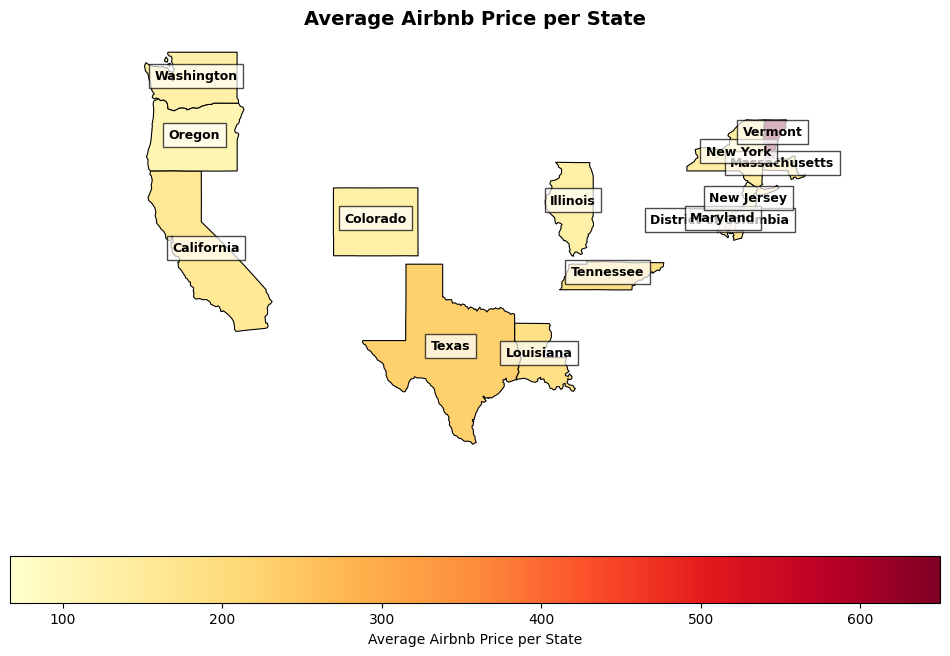

In [30]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Load GeoJSON batas negara bagian AS
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
gdf = gpd.read_file(geojson_url)

# 4️⃣ Pastikan format State menggunakan **nama lengkap** agar cocok dengan GeoJSON
state_mapping = {
    "CA": "California", "TN": "Tennessee", "LA": "Louisiana", "TX": "Texas", "MA": "Massachusetts",
    "IL": "Illinois", "CO": "Colorado", "NY": "New York", "OR": "Oregon", "DC": "District of Columbia",
    "WA": "Washington", "MD": "Maryland", "VT": "Vermont", "NJ": "New Jersey"
}

# Konversi singkatan State ke nama lengkap sebelum merge
df_grouped["State"] = df_grouped["State"].map(state_mapping).fillna(df_grouped["State"])

# 5️⃣ Merge data harga dengan peta (berdasarkan nama lengkap)
gdf = gdf.merge(df_grouped, how="left", left_on="name", right_on="State")

# 🔍 Cek apakah merging berhasil
print(gdf[["name", "Price"]].head(10))  # Jika ada NaN di Price, berarti masih ada yang tidak cocok

# 6️⃣ Plot peta dengan warna harga
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf.plot(column="Price", cmap="YlOrRd", linewidth=0.8, edgecolor="black",
         legend=True, legend_kwds={'label': "Average Airbnb Price per State", 'orientation': "horizontal"}, ax=ax)

# 7️⃣ Tambahkan label singkatan state di tengah tiap negara bagian
for _, row in gdf.iterrows():
    if not pd.isna(row["Price"]):  # Pastikan ada data harga
        centroid = row["geometry"].centroid
        plt.text(centroid.x, centroid.y, row["name"], fontsize=9, ha="center", weight="bold", color="black",
                 bbox=dict(facecolor="white", alpha=0.7, edgecolor="black"))

# 8️⃣ Bersihkan tampilan peta
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
ax.set_title("Average Airbnb Price per State", fontsize=14, fontweight="bold")

# 9️⃣ Simpan gambar
# plt.savefig("airbnb_price_per_state_fixed.png", dpi=300, bbox_inches="tight")
print("\n🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_fixed.png'. Gunakan gambar ini untuk presentasi!")

# 🔟 Tampilkan Peta
plt.show()



🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_final.png'. Gunakan gambar ini untuk presentasi!


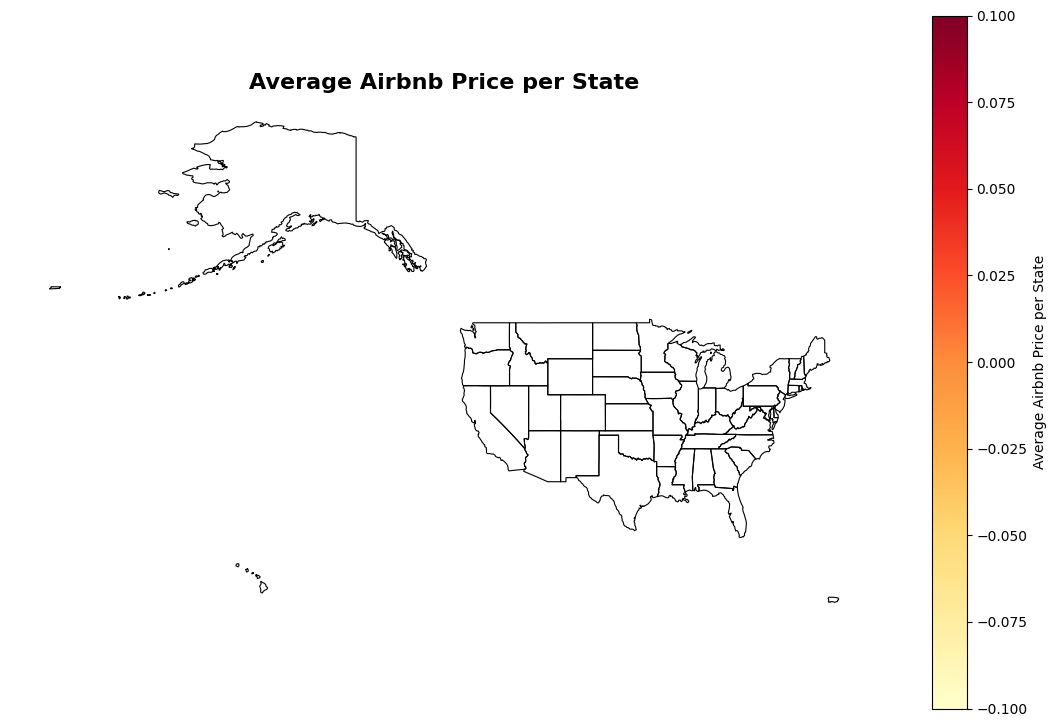

In [31]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon

# 1️⃣ Load dataset Airbnb
df = pd.read_csv('airbnb-listings-us-cleaned-o.csv')

# 2️⃣ Agregasi harga rata-rata per State
df_grouped = df.groupby('State').agg({'Price': 'mean'}).reset_index()

# 3️⃣ Load GeoJSON batas negara bagian AS
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
gdf = gpd.read_file(geojson_url)

# 4️⃣ Mapping singkatan state untuk label
state_abbreviations = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA", "Colorado": "CO",
    "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD",
    "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
}

# Tambahkan singkatan state ke GeoDataFrame
gdf["abbr"] = gdf["name"].map(state_abbreviations)

# 5️⃣ Merge data harga dengan peta berdasarkan nama lengkap state
gdf = gdf.merge(df_grouped, how="left", left_on="name", right_on="State")

# 6️⃣ Plot peta dengan warna heatmap dan batas state yang jelas
fig, ax = plt.subplots(1, 1, figsize=(14, 9))
gdf.boundary.plot(ax=ax, linewidth=0.8, color="black")  # Batas state dengan warna hitam
gdf.plot(column="Price", cmap="YlOrRd", linewidth=0.5, edgecolor="gray",
         legend=True, legend_kwds={'label': "Average Airbnb Price per State", 'orientation': "vertical"}, ax=ax)

# 7️⃣ Tambahkan label singkatan state di tengah tiap negara bagian
for _, row in gdf.iterrows():
    if not pd.isna(row["Price"]):  # Pastikan ada data harga
        centroid = row["geometry"].centroid
        plt.text(centroid.x, centroid.y, row["abbr"], fontsize=9, ha="center", weight="bold", color="black",
                 bbox=dict(facecolor="white", alpha=0.6, edgecolor="black", boxstyle="round,pad=0.3"))

# 8️⃣ Bersihkan tampilan peta
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
ax.set_title("Average Airbnb Price per State", fontsize=16, fontweight="bold")

# 9️⃣ Simpan gambar
plt.savefig("airbnb_price_per_state_final.png", dpi=300, bbox_inches="tight")
print("\n🚀 Peta telah disimpan sebagai 'airbnb_price_per_state_final.png'. Gunakan gambar ini untuk presentasi!")

# 🔟 Tampilkan Peta
plt.show()
